# Jet Engine Hospital: Predictive Maintenance Using NASA C-MAPSS

## Stage 1 — FD001

The objective of this project is to estimate the Remaining Useful Life
of turbofan engines and identify engines that are approaching failure.

The project includes:

- Remaining Useful Life regression
- Failure-risk classification for 10, 20, and 30-cycle horizons
- Anomaly detection
- Uncertainty estimation
- Maintenance decision support

In the FD001 dataset, each engine is represented by a multivariate time
series containing operational settings and 21 sensor measurements.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\User\Desktop\ML\FinalProject


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import SPLITS_DIR
from src.data_loading import (
    add_training_targets,
    load_cmapss_subset,
)
from src.data_splitting import apply_engine_splits

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("Imports completed successfully.")

Imports completed successfully.


## 1. Data Loading

The FD001 subset contains complete run-to-failure trajectories for
100 training engines and truncated trajectories for 100 test engines.

Each observation represents one engine at one operating cycle.

In [3]:
train_df, official_test_df, official_test_rul_df = (
    load_cmapss_subset("FD001")
)

train_labeled_df = add_training_targets(train_df)

print("Training data:", train_df.shape)
print("Official test data:", official_test_df.shape)
print("Official test RUL:", official_test_rul_df.shape)

Training data: (20631, 26)
Official test data: (13096, 26)
Official test RUL: (100, 1)


In [4]:
train_labeled_df.head()

,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,final_cycle,RUL,failure_within_10,failure_within_20,failure_within_30
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192,191,0,0,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192,190,0,0,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192,189,0,0,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192,188,0,0,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192,187,0,0,0


## 2. Dataset Structure

Each row corresponds to one engine-cycle observation.

The original data contains:

- 1 engine identifier
- 1 cycle number
- 3 operational settings
- 21 sensor measurements

In [5]:
dataset_summary = pd.DataFrame(
    {
        "Dataset": [
            "Training",
            "Official test",
            "Official test RUL",
        ],
        "Rows": [
            len(train_df),
            len(official_test_df),
            len(official_test_rul_df),
        ],
        "Columns": [
            train_df.shape[1],
            official_test_df.shape[1],
            official_test_rul_df.shape[1],
        ],
        "Unique engines": [
            train_df["engine_id"].nunique(),
            official_test_df["engine_id"].nunique(),
            official_test_df["engine_id"].nunique(),
        ],
    }
)

dataset_summary

,Dataset,Rows,Columns,Unique engines
0,Training,20631,26,100
1,Official test,13096,26,100
2,Official test RUL,100,1,100


## 3. Example Engine Trajectory

Engine 1 reaches failure at cycle 192. Its RUL decreases by one unit
after each operating cycle and reaches zero at the final cycle.

In [6]:
engine_1 = train_labeled_df.loc[
    train_labeled_df["engine_id"] == 1,
    [
        "engine_id",
        "cycle",
        "final_cycle",
        "RUL",
        "failure_within_10",
        "failure_within_20",
        "failure_within_30",
    ],
]

display(engine_1.head())
display(engine_1.tail())

,engine_id,cycle,final_cycle,RUL,failure_within_10,failure_within_20,failure_within_30
0,1,1,192,191,0,0,0
1,1,2,192,190,0,0,0
2,1,3,192,189,0,0,0
3,1,4,192,188,0,0,0
4,1,5,192,187,0,0,0


,engine_id,cycle,final_cycle,RUL,failure_within_10,failure_within_20,failure_within_30
187,1,188,192,4,1,1,1
188,1,189,192,3,1,1,1
189,1,190,192,2,1,1,1
190,1,191,192,1,1,1,1
191,1,192,192,0,1,1,1


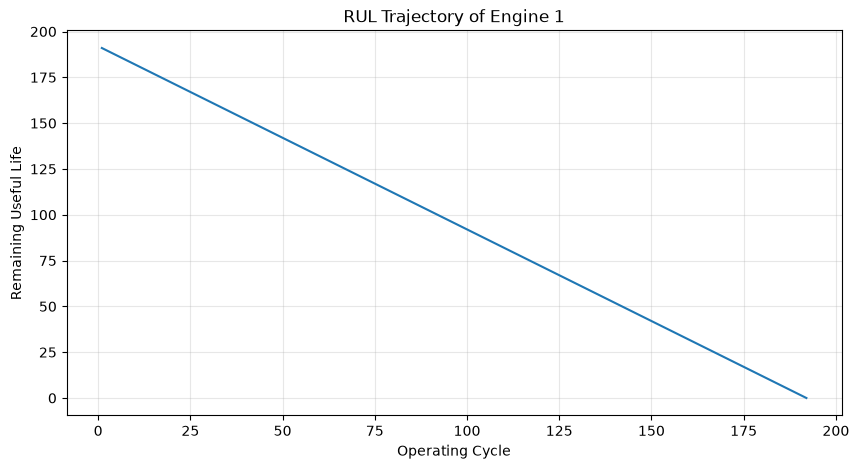

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    engine_1["cycle"],
    engine_1["RUL"],
)

plt.xlabel("Operating Cycle")
plt.ylabel("Remaining Useful Life")
plt.title("RUL Trajectory of Engine 1")
plt.grid(alpha=0.3)
plt.show()

## 4. Leakage-Safe Engine-Level Splitting

The 100 complete training trajectories are divided at the engine level:

- 70 engines for training
- 15 engines for validation
- 15 engines for internal testing

All cycles belonging to one engine remain in the same split.

In [8]:
split_path = SPLITS_DIR / "fd001_engine_splits.json"

with split_path.open(encoding="utf-8") as file:
    split_payload = json.load(file)

engine_splits = split_payload["engine_ids"]

print("Train engines:", len(engine_splits["train"]))
print("Validation engines:", len(engine_splits["validation"]))
print("Internal test engines:", len(engine_splits["test"]))

Train engines: 70
Validation engines: 15
Internal test engines: 15


In [9]:
split_dataframes = apply_engine_splits(
    train_labeled_df,
    engine_splits,
)

train_split_df = split_dataframes["train"]
validation_split_df = split_dataframes["validation"]
internal_test_split_df = split_dataframes["test"]

split_summary = pd.DataFrame(
    {
        "Split": [
            "Train",
            "Validation",
            "Internal test",
        ],
        "Engines": [
            train_split_df["engine_id"].nunique(),
            validation_split_df["engine_id"].nunique(),
            internal_test_split_df["engine_id"].nunique(),
        ],
        "Rows": [
            len(train_split_df),
            len(validation_split_df),
            len(internal_test_split_df),
        ],
    }
)

split_summary

,Split,Engines,Rows
0,Train,70,14507
1,Validation,15,3062
2,Internal test,15,3062


In [10]:
train_ids = set(engine_splits["train"])
validation_ids = set(engine_splits["validation"])
internal_test_ids = set(engine_splits["test"])

overlap_summary = pd.Series(
    {
        "Train ∩ Validation": len(
            train_ids & validation_ids
        ),
        "Train ∩ Internal test": len(
            train_ids & internal_test_ids
        ),
        "Validation ∩ Internal test": len(
            validation_ids & internal_test_ids
        ),
    },
    name="Number of shared engines",
)

overlap_summary

Train ∩ Validation            0
Train ∩ Internal test         0
Validation ∩ Internal test    0
Name: Number of shared engines, dtype: int64

## 5. Initial Data Audit

The dataset is checked for missing values, infinite values, duplicate
engine-cycle keys, and discontinuous cycle sequences.

In [11]:
numeric_values = train_df.select_dtypes(
    include=np.number
)

audit_summary = pd.Series(
    {
        "Rows": len(train_df),
        "Columns": train_df.shape[1],
        "Unique engines": train_df["engine_id"].nunique(),
        "Missing values": int(
            train_df.isna().sum().sum()
        ),
        "Positive infinity values": int(
            np.isposinf(numeric_values.to_numpy()).sum()
        ),
        "Negative infinity values": int(
            np.isneginf(numeric_values.to_numpy()).sum()
        ),
        "Duplicate engine-cycle keys": int(
            train_df[
                ["engine_id", "cycle"]
            ].duplicated().sum()
        ),
    },
    name="FD001 audit",
)

audit_summary

Rows                           20631
Columns                           26
Unique engines                   100
Missing values                     0
Positive infinity values           0
Negative infinity values           0
Duplicate engine-cycle keys        0
Name: FD001 audit, dtype: int64

In [12]:
engines_with_cycle_gaps = []

for engine_id, engine_df in train_df.groupby("engine_id"):
    observed_cycles = engine_df["cycle"].to_numpy()

    expected_cycles = np.arange(
        1,
        observed_cycles.max() + 1,
    )

    if not np.array_equal(
        observed_cycles,
        expected_cycles,
    ):
        engines_with_cycle_gaps.append(int(engine_id))

print(
    "Number of engines with cycle gaps:",
    len(engines_with_cycle_gaps),
)

print(
    "Engine IDs with cycle gaps:",
    engines_with_cycle_gaps,
)

Number of engines with cycle gaps: 0
Engine IDs with cycle gaps: []


In [13]:
engine_lifetimes = (
    train_df.groupby("engine_id")["cycle"]
    .max()
    .rename("lifetime")
)

engine_lifetimes.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: lifetime, dtype: float64

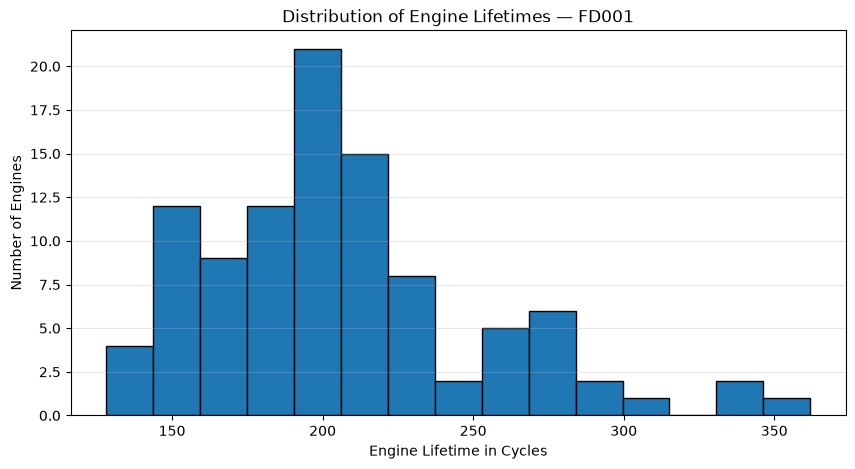

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    engine_lifetimes,
    bins=15,
    edgecolor="black",
)

plt.xlabel("Engine Lifetime in Cycles")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes — FD001")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [15]:
feature_columns = [
    column
    for column in train_df.columns
    if column not in {"engine_id", "cycle"}
]

unique_value_counts = (
    train_split_df[feature_columns]
    .nunique()
    .sort_values()
)

constant_columns = unique_value_counts[
    unique_value_counts <= 1
]

constant_columns

sensor_1                 1
operational_setting_3    1
sensor_5                 1
sensor_10                1
sensor_18                1
sensor_19                1
sensor_16                1
dtype: int64

In [16]:
feature_variances = (
    train_split_df[feature_columns]
    .var()
    .sort_values()
)

feature_variances.head(10)

operational_setting_3    0.000000e+00
sensor_10                0.000000e+00
sensor_18                0.000000e+00
sensor_19                0.000000e+00
sensor_16                1.083410e-34
sensor_5                 3.155661e-30
sensor_1                 1.292559e-26
operational_setting_2    8.581046e-08
sensor_6                 1.886352e-06
operational_setting_1    4.796985e-06
dtype: float64

## 6. Constant and Near-Constant Feature Analysis

Feature variability is examined using only the training split.
Features that are exactly constant contain no predictive information
and are removed from the candidate feature set.

Near-constant features are retained temporarily because raw variance
values are affected by the measurement scale.

In [17]:
feature_audit = pd.DataFrame(
    {
        "n_unique": train_split_df[feature_columns].nunique(),
        "minimum": train_split_df[feature_columns].min(),
        "maximum": train_split_df[feature_columns].max(),
        "mean": train_split_df[feature_columns].mean(),
        "standard_deviation": train_split_df[
            feature_columns
        ].std(),
        "variance": train_split_df[
            feature_columns
        ].var(),
    }
)

feature_audit["range"] = (
    feature_audit["maximum"]
    - feature_audit["minimum"]
)

feature_audit["is_constant"] = (
    feature_audit["n_unique"] == 1
)

feature_audit.sort_values(
    by=["is_constant", "n_unique", "range"],
    ascending=[False, True, True],
)

,n_unique,minimum,maximum,mean,standard_deviation,variance,range,is_constant
operational_setting_3,1,100.0000,100.0000,100.000000,0.000000e+00,0.000000e+00,0.0000,True
sensor_1,1,518.6700,518.6700,518.670000,1.136908e-13,1.292559e-26,0.0000,True
sensor_5,1,14.6200,14.6200,14.620000,1.776418e-15,3.155661e-30,0.0000,True
sensor_10,1,1.3000,1.3000,1.300000,0.000000e+00,0.000000e+00,0.0000,True
sensor_16,1,0.0300,0.0300,0.030000,1.040870e-17,1.083410e-34,0.0000,True
sensor_18,1,2388.0000,2388.0000,2388.000000,0.000000e+00,0.000000e+00,0.0000,True
sensor_19,1,100.0000,100.0000,100.000000,0.000000e+00,0.000000e+00,0.0000,True
sensor_6,2,21.6000,21.6100,21.609808,1.373445e-03,1.886352e-06,0.0100,False
sensor_17,12,388.0000,399.0000,393.198732,1.544015e+00,2.383983e+00,11.0000,False
operational_setting_2,13,-0.0006,0.0006,0.000002,2.929342e-04,8.581046e-08,0.0012,False


In [18]:
constant_features = (
    feature_audit.index[
        feature_audit["is_constant"]
    ]
    .tolist()
)

candidate_features = [
    column
    for column in feature_columns
    if column not in constant_features
]

print("Constant features:")
for feature in constant_features:
    print(f"  - {feature}")

print(
    "\nNumber of original sensor/setting features:",
    len(feature_columns),
)

print(
    "Number of constant features:",
    len(constant_features),
)

print(
    "Number of remaining candidate features:",
    len(candidate_features),
)

Constant features:
  - operational_setting_3
  - sensor_1
  - sensor_5
  - sensor_10
  - sensor_16
  - sensor_18
  - sensor_19

Number of original sensor/setting features: 24
Number of constant features: 7
Number of remaining candidate features: 17


In [19]:
near_constant_candidates = [
    "operational_setting_1",
    "operational_setting_2",
    "sensor_6",
]

feature_audit.loc[
    near_constant_candidates,
    [
        "n_unique",
        "minimum",
        "maximum",
        "range",
        "standard_deviation",
        "variance",
    ],
]

,n_unique,minimum,maximum,range,standard_deviation,variance
operational_setting_1,155,-0.0087,0.0087,0.0174,0.002190,4.796985e-06
operational_setting_2,13,-0.0006,0.0006,0.0012,0.000293,8.581046e-08
sensor_6,2,21.6000,21.6100,0.0100,0.001373,1.886352e-06


## 7. Relationship Between Sensor Features and RUL

Pearson correlation is calculated on the training split to identify
features whose values change as the engines approach failure.

Correlation is used only for exploratory analysis and not as the sole
criterion for final feature selection.

In [20]:
rul_correlations = (
    train_split_df[
        candidate_features + ["RUL"]
    ]
    .corr(numeric_only=True)["RUL"]
    .drop("RUL")
)

correlation_table = pd.DataFrame(
    {
        "correlation_with_RUL": rul_correlations,
        "absolute_correlation": rul_correlations.abs(),
    }
).sort_values(
    "absolute_correlation",
    ascending=False,
)

correlation_table

,correlation_with_RUL,absolute_correlation
sensor_11,-0.688891,0.688891
sensor_4,-0.669270,0.669270
sensor_12,0.662157,0.662157
sensor_7,0.650655,0.650655
sensor_15,-0.634998,0.634998
sensor_21,0.627227,0.627227
sensor_20,0.620936,0.620936
sensor_17,-0.598915,0.598915
sensor_2,-0.598864,0.598864
sensor_3,-0.580502,0.580502


In [21]:
top_correlated_features = (
    correlation_table
    .head(10)
    .copy()
)

top_correlated_features

,correlation_with_RUL,absolute_correlation
sensor_11,-0.688891,0.688891
sensor_4,-0.669270,0.669270
sensor_12,0.662157,0.662157
sensor_7,0.650655,0.650655
sensor_15,-0.634998,0.634998
sensor_21,0.627227,0.627227
sensor_20,0.620936,0.620936
sensor_17,-0.598915,0.598915
sensor_2,-0.598864,0.598864
sensor_3,-0.580502,0.580502


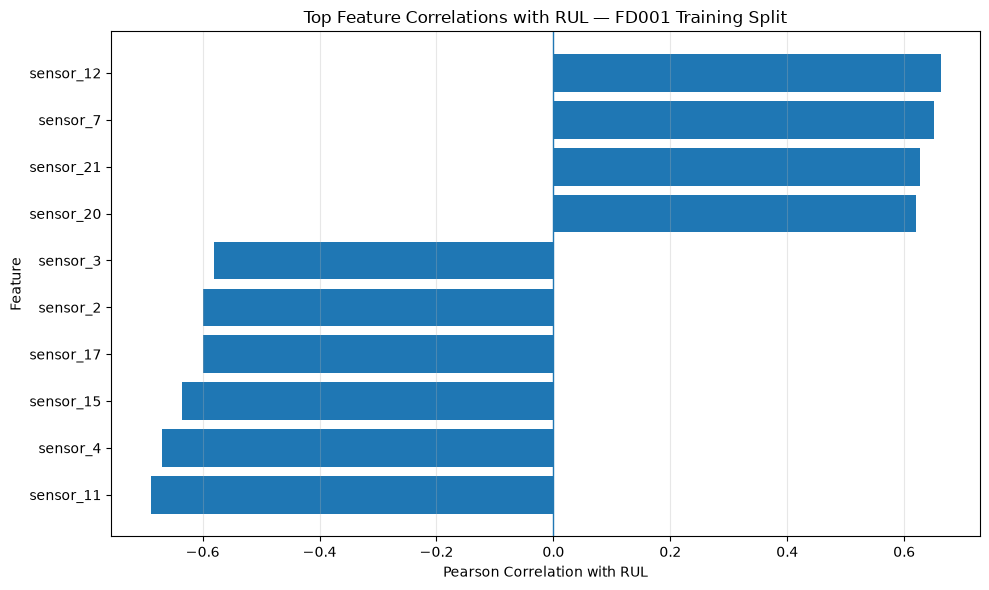

In [22]:
plt.figure(figsize=(10, 6))

plot_data = (
    top_correlated_features[
        "correlation_with_RUL"
    ]
    .sort_values()
)

plt.barh(
    plot_data.index,
    plot_data.values,
)

plt.axvline(
    x=0,
    linewidth=1,
)

plt.xlabel("Pearson Correlation with RUL")
plt.ylabel("Feature")
plt.title(
    "Top Feature Correlations with RUL — FD001 Training Split"
)
plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()
plt.show()

In [23]:
tables_directory = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

tables_directory.mkdir(
    parents=True,
    exist_ok=True,
)

feature_audit.to_csv(
    tables_directory
    / "fd001_feature_audit.csv"
)

correlation_table.to_csv(
    tables_directory
    / "fd001_rul_correlations.csv"
)

print("Feature audit tables saved successfully.")

Feature audit tables saved successfully.


## 8. Sensor Degradation Trajectories

The strongest RUL-correlated sensors are visualized across several
training engines.

The horizontal axis represents Remaining Useful Life. It is reversed
so that the progression from healthy operation toward failure is shown
from left to right.

In [24]:
sample_engine_ids = sorted(
    train_split_df["engine_id"].unique()
)[:4]

sample_engine_ids

[np.int64(2), np.int64(3), np.int64(4), np.int64(6)]

In [25]:
def plot_sensor_trajectories(
    dataframe,
    sensor_name,
    engine_ids,
):
    plt.figure(figsize=(11, 6))

    for engine_id in engine_ids:
        engine_data = (
            dataframe.loc[
                dataframe["engine_id"] == engine_id
            ]
            .sort_values("RUL", ascending=False)
        )

        plt.plot(
            engine_data["RUL"],
            engine_data[sensor_name],
            label=f"Engine {engine_id}",
            alpha=0.8,
        )

    plt.gca().invert_xaxis()

    plt.xlabel("Remaining Useful Life")
    plt.ylabel(sensor_name)
    plt.title(
        f"{sensor_name} Trajectory Toward Failure"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

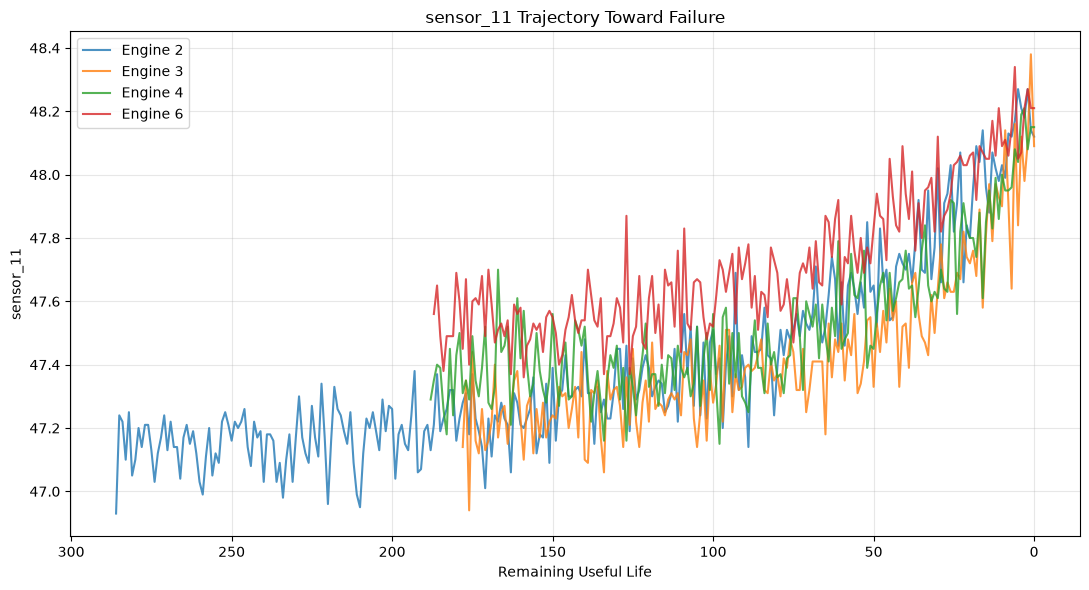

In [26]:
plot_sensor_trajectories(
    dataframe=train_split_df,
    sensor_name="sensor_11",
    engine_ids=sample_engine_ids,
)

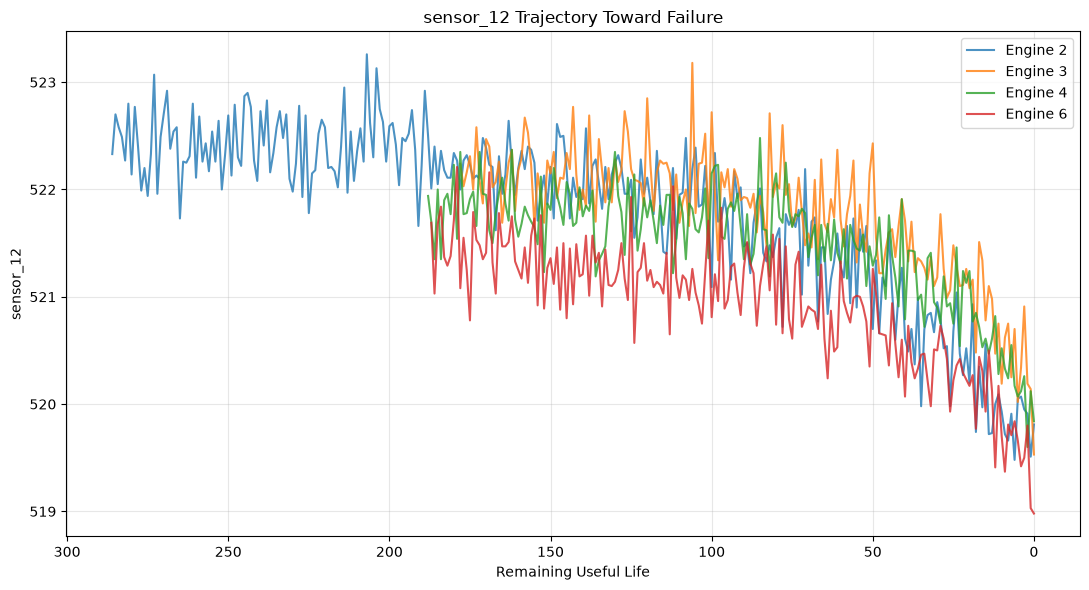

In [27]:
plot_sensor_trajectories(
    dataframe=train_split_df,
    sensor_name="sensor_12",
    engine_ids=sample_engine_ids,
)

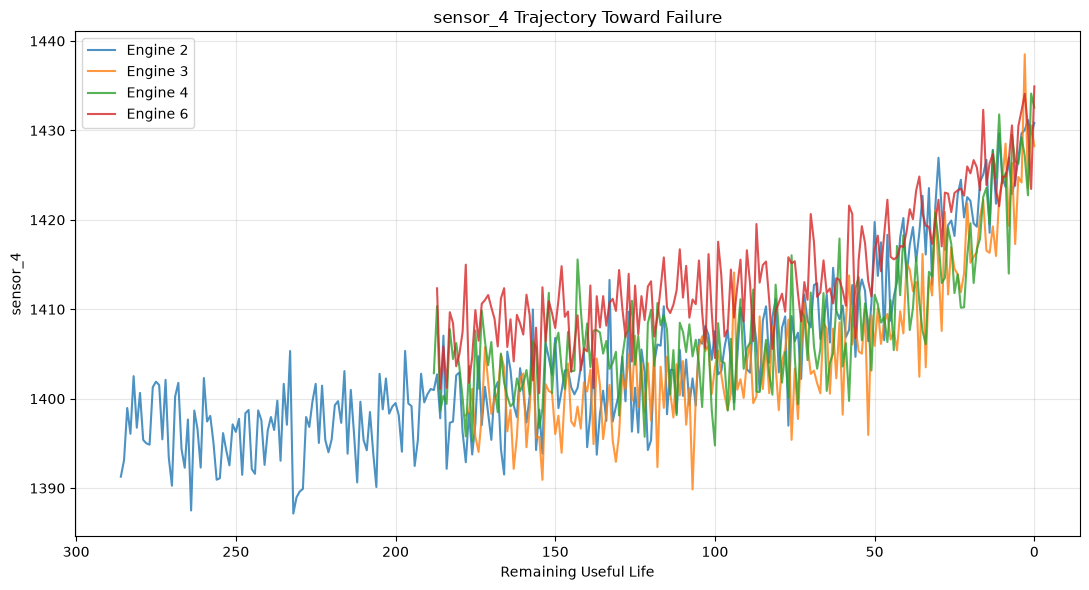

In [28]:
plot_sensor_trajectories(
    dataframe=train_split_df,
    sensor_name="sensor_4",
    engine_ids=sample_engine_ids,
)

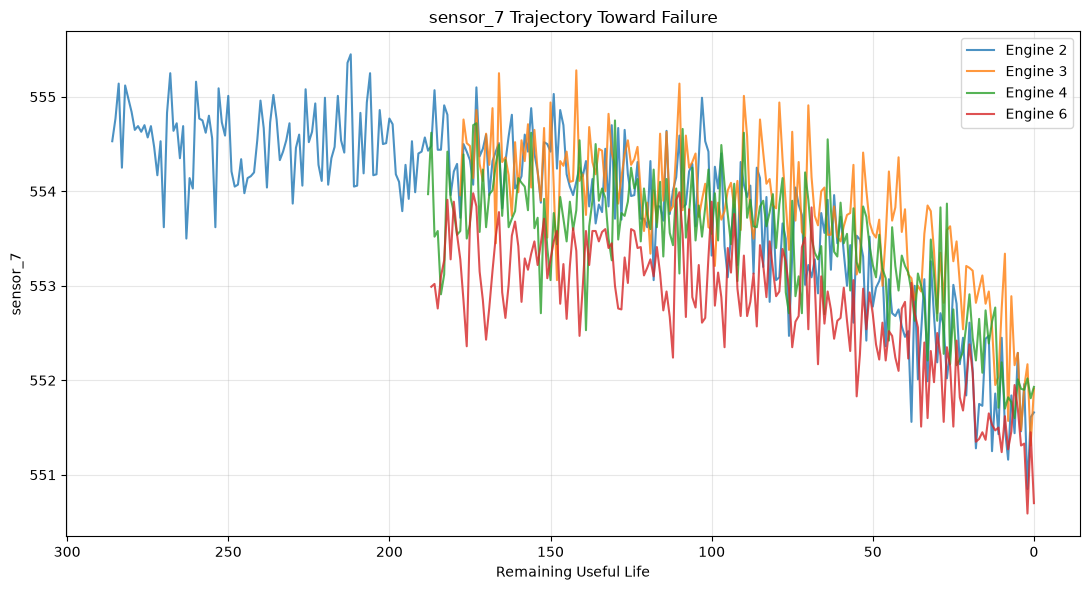

In [29]:
plot_sensor_trajectories(
    dataframe=train_split_df,
    sensor_name="sensor_7",
    engine_ids=sample_engine_ids,
)

In [30]:
def calculate_mean_sensor_by_rul(
    dataframe,
    sensor_name,
    maximum_rul=150,
):
    filtered_data = dataframe.loc[
        dataframe["RUL"] <= maximum_rul,
        ["RUL", sensor_name],
    ]

    mean_trajectory = (
        filtered_data
        .groupby("RUL")[sensor_name]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("RUL", ascending=False)
    )

    return mean_trajectory

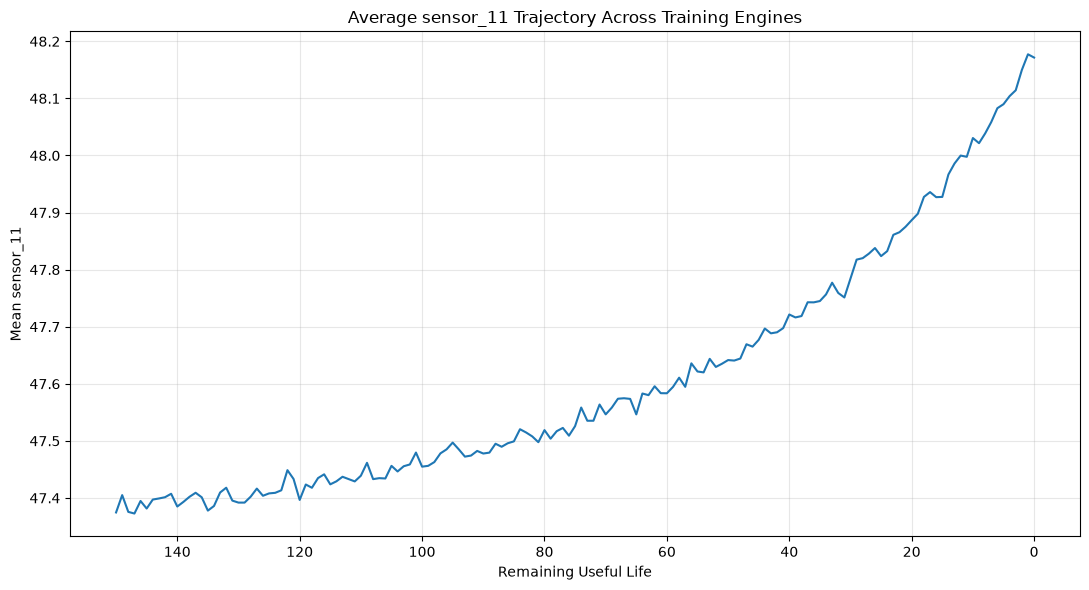

In [31]:
sensor_11_mean = calculate_mean_sensor_by_rul(
    train_split_df,
    "sensor_11",
)

plt.figure(figsize=(11, 6))

plt.plot(
    sensor_11_mean["RUL"],
    sensor_11_mean["mean"],
)

plt.gca().invert_xaxis()

plt.xlabel("Remaining Useful Life")
plt.ylabel("Mean sensor_11")
plt.title(
    "Average sensor_11 Trajectory Across Training Engines"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

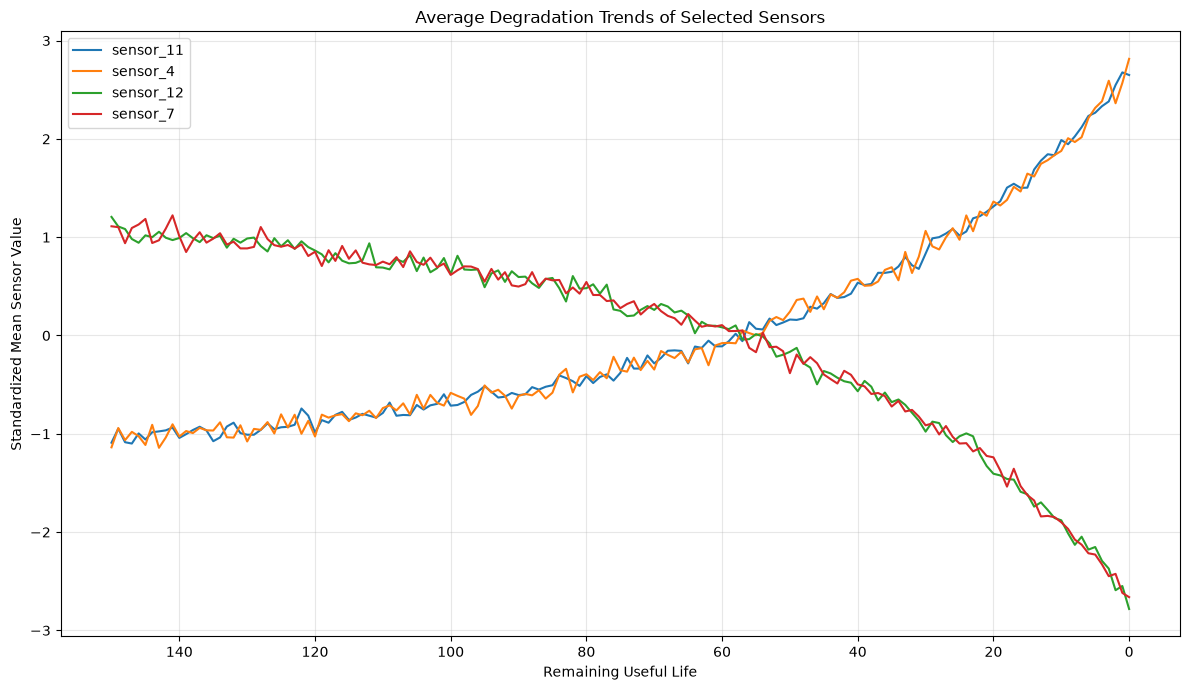

In [32]:
selected_sensors = [
    "sensor_11",
    "sensor_4",
    "sensor_12",
    "sensor_7",
]

plt.figure(figsize=(12, 7))

for sensor_name in selected_sensors:
    sensor_mean = calculate_mean_sensor_by_rul(
        train_split_df,
        sensor_name,
    )

    standardized_mean = (
        sensor_mean["mean"]
        - sensor_mean["mean"].mean()
    ) / sensor_mean["mean"].std()

    plt.plot(
        sensor_mean["RUL"],
        standardized_mean,
        label=sensor_name,
    )

plt.gca().invert_xaxis()

plt.xlabel("Remaining Useful Life")
plt.ylabel("Standardized Mean Sensor Value")
plt.title(
    "Average Degradation Trends of Selected Sensors"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Leakage-Safe Time-Series Feature Engineering

Raw sensor measurements can be noisy. Therefore, temporal features are
created to describe recent sensor behavior.

For each non-constant sensor, the following features are generated:

- Changes over 1 and 5 cycles
- Rolling means over 5, 10, and 20 cycles
- Rolling standard deviations over 5, 10, and 20 cycles

All calculations are performed separately for each engine and use only
the current and previous observations.

In [33]:
sensor_columns = [
    column
    for column in train_split_df.columns
    if column.startswith("sensor_")
]

candidate_sensor_columns = [
    column
    for column in sensor_columns
    if column not in constant_features
]

print("Original sensor count:", len(sensor_columns))
print(
    "Non-constant sensor count:",
    len(candidate_sensor_columns),
)

print("\nSensors used for temporal features:")

for sensor_name in candidate_sensor_columns:
    print(f"  - {sensor_name}")

Original sensor count: 21
Non-constant sensor count: 15

Sensors used for temporal features:
  - sensor_2
  - sensor_3
  - sensor_4
  - sensor_6
  - sensor_7
  - sensor_8
  - sensor_9
  - sensor_11
  - sensor_12
  - sensor_13
  - sensor_14
  - sensor_15
  - sensor_17
  - sensor_20
  - sensor_21


In [44]:
import importlib
import src.feature_engineering as fe

importlib.reload(fe)

build_time_series_features = fe.build_time_series_features
get_model_feature_columns = fe.get_model_feature_columns

print("Optimized feature-engineering module loaded.")

Optimized feature-engineering module loaded.


In [45]:
train_features_df = build_time_series_features(
    train_split_df,
    sensor_columns=candidate_sensor_columns,
)

validation_features_df = build_time_series_features(
    validation_split_df,
    sensor_columns=candidate_sensor_columns,
)

internal_test_features_df = build_time_series_features(
    internal_test_split_df,
    sensor_columns=candidate_sensor_columns,
)

print("Train:", train_features_df.shape)
print("Validation:", validation_features_df.shape)
print("Internal test:", internal_test_features_df.shape)

Train: (14507, 151)
Validation: (3062, 151)
Internal test: (3062, 151)


In [46]:
model_feature_columns = get_model_feature_columns(
    train_features_df,
    constant_features=constant_features,
)

feature_engineering_summary = pd.Series(
    {
        "Train rows": len(train_features_df),
        "Validation rows": len(validation_features_df),
        "Internal test rows": len(
            internal_test_features_df
        ),
        "Total columns": train_features_df.shape[1],
        "Model feature count": len(
            model_feature_columns
        ),
        "Missing feature values": int(
            train_features_df[
                model_feature_columns
            ].isna().sum().sum()
        ),
        "Infinite feature values": int(
            np.isinf(
                train_features_df[
                    model_feature_columns
                ].to_numpy()
            ).sum()
        ),
    },
    name="Feature engineering audit",
)

feature_engineering_summary

Train rows                 14507
Validation rows             3062
Internal test rows          3062
Total columns                151
Model feature count          138
Missing feature values         0
Infinite feature values        0
Name: Feature engineering audit, dtype: int64

In [47]:
first_rows_per_engine = (
    train_features_df
    .groupby("engine_id")
    .head(1)
)

delta_columns = [
    column
    for column in train_features_df.columns
    if "_delta_" in column
]

maximum_first_row_delta = (
    first_rows_per_engine[delta_columns]
    .abs()
    .to_numpy()
    .max()
)

print(
    "Maximum absolute delta in first engine cycles:",
    maximum_first_row_delta,
)

Maximum absolute delta in first engine cycles: 0.0


In [48]:
sensor_11_feature_columns = [
    column
    for column in train_features_df.columns
    if column.startswith("sensor_11")
]

train_features_df.loc[
    train_features_df["engine_id"] == 2,
    [
        "engine_id",
        "cycle",
        "RUL",
        *sensor_11_feature_columns,
    ],
].head(10)

,engine_id,cycle,RUL,sensor_11,sensor_11_delta_1,sensor_11_delta_5,sensor_11_mean_5,sensor_11_std_5,sensor_11_mean_10,sensor_11_std_10,sensor_11_mean_20,sensor_11_std_20
0,2,1,286,46.93,0.00,0.00,46.9300,0.000000,46.930000,0.000000,46.930000,0.000000
1,2,2,285,47.24,0.31,0.00,47.0850,0.155000,47.085000,0.155000,47.085000,0.155000
2,2,3,284,47.22,-0.02,0.00,47.1300,0.141657,47.130000,0.141657,47.130000,0.141657
3,2,4,283,47.10,-0.12,0.00,47.1225,0.123364,47.122500,0.123364,47.122500,0.123364
4,2,5,282,47.25,0.15,0.00,47.1480,0.121557,47.148000,0.121557,47.148000,0.121557
5,2,6,281,47.05,-0.20,0.12,47.1720,0.081339,47.131667,0.116821,47.131667,0.116821
6,2,7,280,47.10,0.05,-0.14,47.1440,0.077097,47.127143,0.108722,47.127143,0.108722
7,2,8,279,47.20,0.10,-0.02,47.1400,0.073485,47.136250,0.104515,47.136250,0.104515
8,2,9,278,47.14,-0.06,0.04,47.1480,0.070824,47.136667,0.098545,47.136667,0.098545
9,2,10,277,47.21,0.07,-0.04,47.1400,0.060332,47.144000,0.096042,47.144000,0.096042


## 10. Baseline RUL Regression

Three validation experiments are performed:

1. Mean Dummy Regressor
2. Ridge Regression using raw features
3. Ridge Regression using raw and temporal features

The internal test split remains untouched during model development.

In [49]:
from src.regression import (
    evaluate_regression,
    make_dummy_regressor,
    make_ridge_regressor,
)

print("Regression utilities imported successfully.")

Regression utilities imported successfully.


In [57]:
import importlib
import src.regression as regression_module

importlib.reload(regression_module)

evaluate_regression = (
    regression_module.evaluate_regression
)

evaluate_rul_regions = (
    regression_module.evaluate_rul_regions
)

make_dummy_regressor = (
    regression_module.make_dummy_regressor
)

make_ridge_regressor = (
    regression_module.make_ridge_regressor
)

make_polynomial_ridge_regressor = (
    regression_module.make_polynomial_ridge_regressor
)

make_random_forest_regressor = (
    regression_module.make_random_forest_regressor
)

make_gradient_boosting_regressor = (
    regression_module.make_gradient_boosting_regressor
)

print("Expanded regression models loaded.")

Expanded regression models loaded.


In [50]:
raw_feature_columns = [
    "cycle",
    *candidate_features,
]

temporal_feature_columns = (
    model_feature_columns
)

print(
    "Raw feature count:",
    len(raw_feature_columns),
)

print(
    "Raw + temporal feature count:",
    len(temporal_feature_columns),
)

Raw feature count: 18
Raw + temporal feature count: 138


In [51]:
target_column = "RUL"

X_train_raw = train_features_df[
    raw_feature_columns
]

X_validation_raw = validation_features_df[
    raw_feature_columns
]

X_train_temporal = train_features_df[
    temporal_feature_columns
]

X_validation_temporal = validation_features_df[
    temporal_feature_columns
]

y_train = train_features_df[
    target_column
]

y_validation = validation_features_df[
    target_column
]

print(
    "Raw training matrix:",
    X_train_raw.shape,
)

print(
    "Temporal training matrix:",
    X_train_temporal.shape,
)

print(
    "Validation target:",
    y_validation.shape,
)

Raw training matrix: (14507, 18)
Temporal training matrix: (14507, 138)
Validation target: (3062,)


In [52]:
regression_experiments = [
    {
        "name": "Dummy Mean",
        "model": make_dummy_regressor(),
        "train_features": X_train_raw,
        "validation_features": X_validation_raw,
    },
    {
        "name": "Ridge — Raw Features",
        "model": make_ridge_regressor(
            alpha=1.0
        ),
        "train_features": X_train_raw,
        "validation_features": X_validation_raw,
    },
    {
        "name": "Ridge — Temporal Features",
        "model": make_ridge_regressor(
            alpha=1.0
        ),
        "train_features": X_train_temporal,
        "validation_features": (
            X_validation_temporal
        ),
    },
]

regression_results = []
validation_predictions = {}
trained_regression_models = {}

for experiment in regression_experiments:
    model_name = experiment["name"]
    model = experiment["model"]

    model.fit(
        experiment["train_features"],
        y_train,
    )

    predictions = model.predict(
        experiment["validation_features"]
    )

    # RUL cannot be negative.
    predictions = np.clip(
        predictions,
        a_min=0,
        a_max=None,
    )

    regression_results.append(
        evaluate_regression(
            model_name=model_name,
            y_true=y_validation,
            y_pred=predictions,
        )
    )

    validation_predictions[
        model_name
    ] = predictions

    trained_regression_models[
        model_name
    ] = model

print("Baseline regression experiments completed.")

Baseline regression experiments completed.


In [53]:
regression_results_df = (
    pd.DataFrame(regression_results)
    .sort_values(
        by="RMSE",
        ascending=True,
    )
    .reset_index(drop=True)
)

regression_results_df.round(4)

,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate
0,Ridge — Temporal Features,24.0492,31.2335,0.7721,2.896884e+05,11.6594,0.5431
1,Ridge — Raw Features,23.8141,31.4604,0.7688,4.201686e+05,12.1203,0.5212
2,Dummy Mean,55.3094,65.5053,-0.0024,1.548785e+07,93.8193,0.5340


In [54]:
best_model_name = (
    regression_results_df.loc[
        0,
        "Model",
    ]
)

best_validation_predictions = (
    validation_predictions[
        best_model_name
    ]
)

print(
    "Best validation model:",
    best_model_name,
)

Best validation model: Ridge — Temporal Features


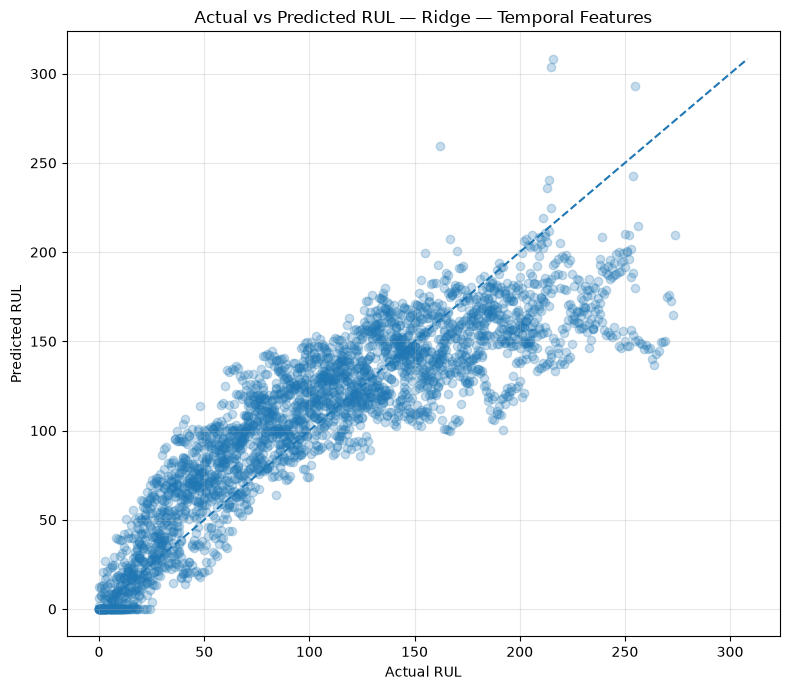

In [55]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_validation,
    best_validation_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_validation.min(),
    best_validation_predictions.min(),
)

maximum_value = max(
    y_validation.max(),
    best_validation_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title(
    f"Actual vs Predicted RUL — {best_model_name}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
regression_results_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "fd001_baseline_regression_results.csv",
    index=False,
)

print("Regression results saved successfully.")

Regression results saved successfully.


In [58]:
from time import perf_counter

expanded_experiments = [
    {
        "name": "Dummy Mean",
        "model": make_dummy_regressor(),
        "train_features": X_train_raw,
        "validation_features": X_validation_raw,
    },
    {
        "name": "Ridge — Raw",
        "model": make_ridge_regressor(
            alpha=1.0
        ),
        "train_features": X_train_raw,
        "validation_features": X_validation_raw,
    },
    {
        "name": "Polynomial Ridge — Raw",
        "model": (
            make_polynomial_ridge_regressor(
                degree=2,
                alpha=10.0,
            )
        ),
        "train_features": X_train_raw,
        "validation_features": X_validation_raw,
    },
    {
        "name": "Ridge — Temporal",
        "model": make_ridge_regressor(
            alpha=1.0
        ),
        "train_features": X_train_temporal,
        "validation_features": X_validation_temporal,
    },
    {
        "name": "Random Forest — Temporal",
        "model": (
            make_random_forest_regressor()
        ),
        "train_features": X_train_temporal,
        "validation_features": X_validation_temporal,
    },
    {
        "name": "Gradient Boosting — Temporal",
        "model": (
            make_gradient_boosting_regressor()
        ),
        "train_features": X_train_temporal,
        "validation_features": X_validation_temporal,
    },
]

expanded_results = []
expanded_predictions = {}
expanded_models = {}

for experiment in expanded_experiments:
    model_name = experiment["name"]
    model = experiment["model"]

    print(f"Training: {model_name}")

    fit_start = perf_counter()

    model.fit(
        experiment["train_features"],
        y_train,
    )

    fit_seconds = (
        perf_counter() - fit_start
    )

    prediction_start = perf_counter()

    predictions = model.predict(
        experiment["validation_features"]
    )

    prediction_seconds = (
        perf_counter() - prediction_start
    )

    predictions = np.clip(
        predictions,
        a_min=0,
        a_max=None,
    )

    metrics = evaluate_regression(
        model_name=model_name,
        y_true=y_validation,
        y_pred=predictions,
    )

    metrics["Fit time (seconds)"] = (
        fit_seconds
    )

    metrics[
        "Prediction ms per 1000 rows"
    ] = (
        prediction_seconds
        * 1_000_000
        / len(predictions)
    )

    expanded_results.append(metrics)

    expanded_predictions[
        model_name
    ] = predictions

    expanded_models[
        model_name
    ] = model

print("All expanded models completed.")

Training: Dummy Mean
Training: Ridge — Raw
Training: Polynomial Ridge — Raw
Training: Ridge — Temporal
Training: Random Forest — Temporal
Training: Gradient Boosting — Temporal
All expanded models completed.


In [59]:
expanded_results_df = (
    pd.DataFrame(expanded_results)
    .sort_values(
        by=["NASA Score", "RMSE"],
        ascending=True,
    )
    .reset_index(drop=True)
)

expanded_results_df.round(4)

,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Fit time (seconds),Prediction ms per 1000 rows
0,Polynomial Ridge — Raw,21.1126,28.2155,0.8140,1.499259e+05,7.8372,0.4589,0.1257,3.4566
1,Gradient Boosting — Temporal,24.3592,32.1944,0.7579,2.443606e+05,6.1502,0.4732,111.4165,6.8969
2,Ridge — Temporal,24.0492,31.2335,0.7721,2.896884e+05,11.6594,0.5431,0.1060,2.4835
3,Random Forest — Temporal,23.8124,32.7154,0.7500,3.183145e+05,3.8733,0.4517,35.0386,97.8807
4,Ridge — Raw,23.8141,31.4604,0.7688,4.201686e+05,12.1203,0.5212,0.0174,2.6833
5,Dummy Mean,55.3094,65.5053,-0.0024,1.548785e+07,93.8193,0.5340,0.0056,0.0644


In [60]:
best_validation_model_name = (
    expanded_results_df.loc[
        0,
        "Model",
    ]
)

best_validation_predictions = (
    expanded_predictions[
        best_validation_model_name
    ]
)

regional_results = (
    evaluate_rul_regions(
        model_name=best_validation_model_name,
        y_true=y_validation,
        y_pred=best_validation_predictions,
    )
)

regional_results_df = pd.DataFrame(
    regional_results
)

regional_results_df.round(4)

,Model,Region,Samples,MAE,RMSE,Bias
0,Polynomial Ridge — Raw,Near failure: RUL 0–30,465,7.8372,10.5055,1.6873
1,Polynomial Ridge — Raw,Mid life: RUL 31–125,1425,18.2484,21.9983,7.6621
2,Polynomial Ridge — Raw,Early life: RUL > 125,1172,29.8622,38.0496,-21.7372


In [61]:
expanded_results_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "fd001_expanded_regression_results.csv",
    index=False,
)

regional_results_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "fd001_regression_region_results.csv",
    index=False,
)

print("Expanded regression results saved.")

Expanded regression results saved.


In [62]:
all_regional_results = []

for model_name, predictions in expanded_predictions.items():
    all_regional_results.extend(
        evaluate_rul_regions(
            model_name=model_name,
            y_true=y_validation,
            y_pred=predictions,
        )
    )

all_regional_results_df = (
    pd.DataFrame(all_regional_results)
    .sort_values(
        by=["Region", "MAE"],
        ascending=True,
    )
    .reset_index(drop=True)
)

all_regional_results_df.round(4)

,Model,Region,Samples,MAE,RMSE,Bias
0,Polynomial Ridge — Raw,Early life: RUL > 125,1172,29.8622,38.0496,-21.7372
1,Ridge — Temporal,Early life: RUL > 125,1172,30.5747,39.2120,-22.5390
2,Ridge — Raw,Early life: RUL > 125,1172,31.6527,41.4141,-27.6001
3,Gradient Boosting — Temporal,Early life: RUL > 125,1172,35.7095,43.0799,-20.4428
4,Random Forest — Temporal,Early life: RUL > 125,1172,35.8013,43.8624,-21.1001
5,Dummy Mean,Early life: RUL > 125,1172,66.2473,74.9494,-66.2473
6,Polynomial Ridge — Raw,Mid life: RUL 31–125,1425,18.2484,21.9983,7.6621
7,Random Forest — Temporal,Mid life: RUL 31–125,1425,20.4584,26.6357,5.6809
8,Gradient Boosting — Temporal,Mid life: RUL 31–125,1425,20.9659,26.1333,6.1278
9,Ridge — Raw,Mid life: RUL 31–125,1425,21.1830,25.0653,14.8659


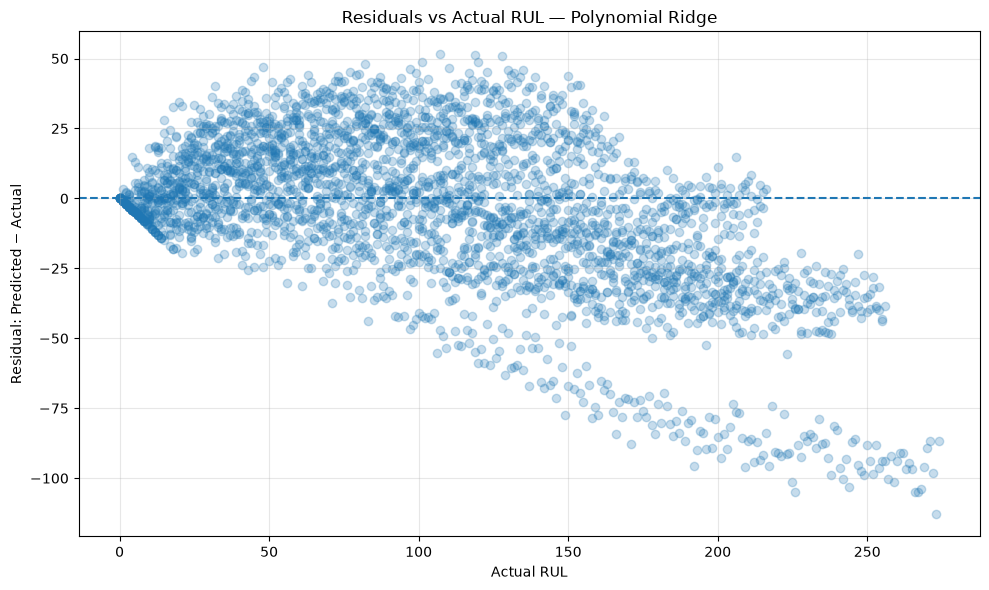

In [63]:
selected_model_name = "Polynomial Ridge — Raw"

selected_predictions = expanded_predictions[
    selected_model_name
]

residuals = (
    selected_predictions
    - y_validation.to_numpy()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    y_validation,
    residuals,
    alpha=0.25,
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.5,
)

plt.xlabel("Actual RUL")
plt.ylabel("Residual: Predicted − Actual")
plt.title(
    "Residuals vs Actual RUL — Polynomial Ridge"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "fd001_polynomial_ridge_residuals.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [64]:
validation_prediction_df = (
    validation_features_df[
        ["engine_id", "cycle", "RUL"]
    ]
    .copy()
)

validation_prediction_df[
    "predicted_RUL"
] = selected_predictions

validation_prediction_df[
    "error"
] = (
    validation_prediction_df["predicted_RUL"]
    - validation_prediction_df["RUL"]
)

validation_prediction_df.head()

,engine_id,cycle,RUL,predicted_RUL,error
0,13,1,162,191.416883,29.416883
1,13,2,161,179.744480,18.744480
2,13,3,160,176.604017,16.604017
3,13,4,159,182.745475,23.745475
4,13,5,158,189.470674,31.470674


In [65]:
validation_engine_lengths = (
    validation_prediction_df
    .groupby("engine_id")["cycle"]
    .max()
    .sort_values()
)

representative_engine_ids = [
    int(validation_engine_lengths.index[0]),
    int(
        validation_engine_lengths.index[
            len(validation_engine_lengths) // 2
        ]
    ),
    int(validation_engine_lengths.index[-1]),
]

print(
    "Representative engines:",
    representative_engine_ids,
)

Representative engines: [91, 16, 56]


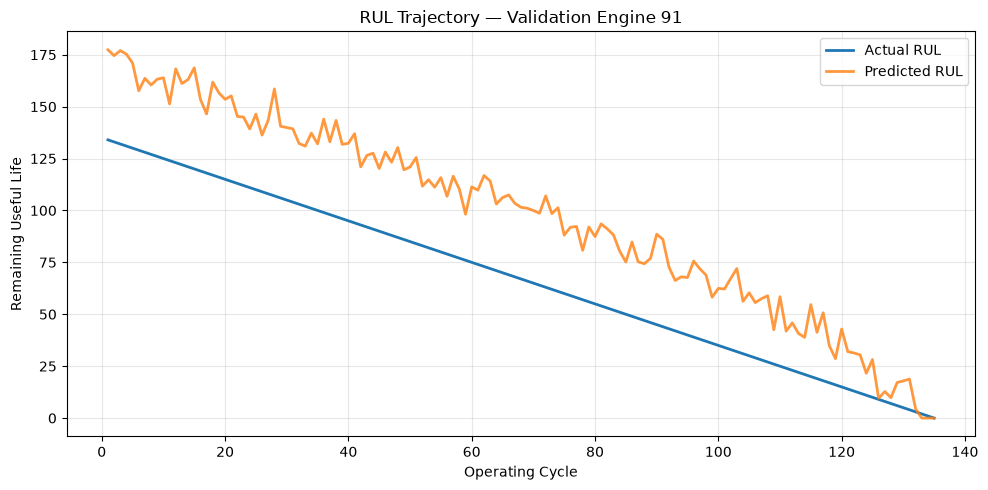

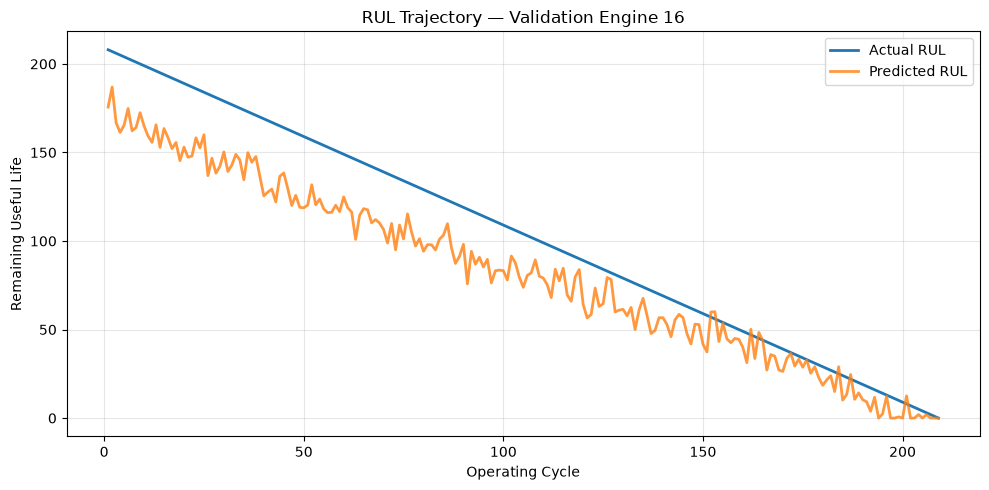

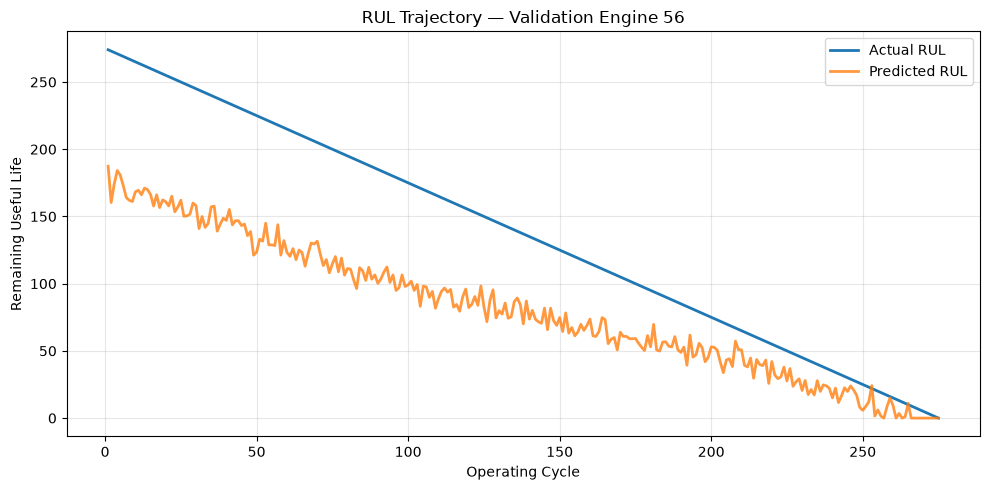

In [66]:
for engine_id in representative_engine_ids:
    engine_predictions = (
        validation_prediction_df.loc[
            validation_prediction_df[
                "engine_id"
            ] == engine_id
        ]
        .sort_values("cycle")
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        engine_predictions["cycle"],
        engine_predictions["RUL"],
        label="Actual RUL",
        linewidth=2,
    )

    plt.plot(
        engine_predictions["cycle"],
        engine_predictions[
            "predicted_RUL"
        ],
        label="Predicted RUL",
        linewidth=2,
        alpha=0.8,
    )

    plt.xlabel("Operating Cycle")
    plt.ylabel("Remaining Useful Life")

    plt.title(
        f"RUL Trajectory — Validation Engine {engine_id}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        PROJECT_ROOT
        / "reports"
        / "figures"
        / f"fd001_engine_{engine_id}_rul_trajectory.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

## 11. Polynomial Ridge Hyperparameter Tuning

The best overall validation model is Polynomial Ridge. Its regularization
strength is tuned using only the validation split.

Two feature configurations are compared:

- Raw features including operating cycle
- Raw features excluding operating cycle

The internal test split remains untouched.

In [67]:
raw_features_with_cycle = raw_feature_columns

raw_features_without_cycle = [
    column
    for column in raw_feature_columns
    if column != "cycle"
]

feature_configurations = {
    "Raw with cycle": raw_features_with_cycle,
    "Raw without cycle": raw_features_without_cycle,
}

for configuration_name, columns in feature_configurations.items():
    print(
        configuration_name,
        "→",
        len(columns),
        "features",
    )

Raw with cycle → 18 features
Raw without cycle → 17 features


In [68]:
from time import perf_counter

polynomial_alpha_values = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
]

polynomial_tuning_results = []
polynomial_tuning_models = {}
polynomial_tuning_predictions = {}

for configuration_name, feature_columns in (
    feature_configurations.items()
):
    X_train_configuration = train_features_df[
        feature_columns
    ]

    X_validation_configuration = validation_features_df[
        feature_columns
    ]

    for alpha in polynomial_alpha_values:
        experiment_name = (
            f"Polynomial Ridge | "
            f"{configuration_name} | "
            f"alpha={alpha}"
        )

        print(f"Training: {experiment_name}")

        model = make_polynomial_ridge_regressor(
            degree=2,
            alpha=alpha,
        )

        start_time = perf_counter()

        model.fit(
            X_train_configuration,
            y_train,
        )

        fit_seconds = perf_counter() - start_time

        predictions = model.predict(
            X_validation_configuration
        )

        predictions = np.clip(
            predictions,
            a_min=0,
            a_max=None,
        )

        metrics = evaluate_regression(
            model_name=experiment_name,
            y_true=y_validation,
            y_pred=predictions,
        )

        metrics["Feature configuration"] = (
            configuration_name
        )

        metrics["Alpha"] = alpha
        metrics["Fit time (seconds)"] = fit_seconds

        polynomial_tuning_results.append(
            metrics
        )

        polynomial_tuning_models[
            experiment_name
        ] = model

        polynomial_tuning_predictions[
            experiment_name
        ] = predictions

print("Polynomial Ridge tuning completed.")

Training: Polynomial Ridge | Raw with cycle | alpha=0.01
Training: Polynomial Ridge | Raw with cycle | alpha=0.1
Training: Polynomial Ridge | Raw with cycle | alpha=1.0
Training: Polynomial Ridge | Raw with cycle | alpha=10.0
Training: Polynomial Ridge | Raw with cycle | alpha=100.0
Training: Polynomial Ridge | Raw with cycle | alpha=1000.0
Training: Polynomial Ridge | Raw without cycle | alpha=0.01
Training: Polynomial Ridge | Raw without cycle | alpha=0.1
Training: Polynomial Ridge | Raw without cycle | alpha=1.0
Training: Polynomial Ridge | Raw without cycle | alpha=10.0
Training: Polynomial Ridge | Raw without cycle | alpha=100.0
Training: Polynomial Ridge | Raw without cycle | alpha=1000.0
Polynomial Ridge tuning completed.


In [69]:
polynomial_tuning_df = (
    pd.DataFrame(
        polynomial_tuning_results
    )
    .sort_values(
        by=[
            "NASA Score",
            "RMSE",
        ],
        ascending=True,
    )
    .reset_index(drop=True)
)

polynomial_tuning_df[
    [
        "Model",
        "Feature configuration",
        "Alpha",
        "MAE",
        "RMSE",
        "R2",
        "NASA Score",
        "Near-failure MAE",
        "Late prediction rate",
        "Fit time (seconds)",
    ]
].round(4)

,Model,Feature configuration,Alpha,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Fit time (seconds)
0,Polynomial Ridge | Raw with cycle | alpha=0.01,Raw with cycle,0.01,21.8468,28.6333,0.8085,1.137667e+05,9.6138,0.4504,0.1314
1,Polynomial Ridge | Raw with cycle | alpha=0.1,Raw with cycle,0.10,21.3700,28.2959,0.8130,1.185402e+05,8.1891,0.4543,0.1084
2,Polynomial Ridge | Raw with cycle | alpha=1.0,Raw with cycle,1.00,21.0873,28.1059,0.8155,1.351514e+05,7.6194,0.4491,0.1051
3,Polynomial Ridge | Raw with cycle | alpha=10.0,Raw with cycle,10.00,21.1126,28.2155,0.8140,1.499259e+05,7.8372,0.4589,0.1023
4,Polynomial Ridge | Raw with cycle | alpha=100.0,Raw with cycle,100.00,21.1723,28.3218,0.8126,1.609605e+05,8.0749,0.4680,0.1018
5,Polynomial Ridge | Raw with cycle | alpha=1000.0,Raw with cycle,1000.00,21.8513,29.1212,0.8019,2.172589e+05,9.3189,0.4889,0.1067
6,Polynomial Ridge | Raw without cycle | alpha=0.01,Raw without cycle,0.01,25.7272,36.2805,0.6925,3.951705e+06,7.9875,0.4798,0.1016
7,Polynomial Ridge | Raw without cycle | alpha=0.1,Raw without cycle,0.10,25.8752,36.4226,0.6901,4.170742e+06,7.8105,0.4801,0.0942
8,Polynomial Ridge | Raw without cycle | alpha=1.0,Raw without cycle,1.00,27.0464,37.4176,0.6729,4.961354e+06,8.9042,0.4853,0.1104
9,Polynomial Ridge | Raw without cycle | alpha=1...,Raw without cycle,1000.00,28.4426,38.5539,0.6527,5.089397e+06,10.0553,0.4912,0.0942


In [70]:
best_tuned_model_name = (
    polynomial_tuning_df.loc[
        0,
        "Model",
    ]
)

best_tuned_configuration = (
    polynomial_tuning_df.loc[
        0,
        "Feature configuration",
    ]
)

best_tuned_alpha = (
    polynomial_tuning_df.loc[
        0,
        "Alpha",
    ]
)

best_tuned_model = (
    polynomial_tuning_models[
        best_tuned_model_name
    ]
)

best_tuned_predictions = (
    polynomial_tuning_predictions[
        best_tuned_model_name
    ]
)

print("Best tuned model:")
print(best_tuned_model_name)

print(
    "\nBest feature configuration:",
    best_tuned_configuration,
)

print(
    "Best alpha:",
    best_tuned_alpha,
)

Best tuned model:
Polynomial Ridge | Raw with cycle | alpha=0.01

Best feature configuration: Raw with cycle
Best alpha: 0.01


In [71]:
polynomial_tuning_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "fd001_polynomial_ridge_tuning.csv",
    index=False,
)

print("Polynomial Ridge tuning results saved.")

Polynomial Ridge tuning results saved.


## 12. Final Internal-Test Evaluation

Polynomial Ridge with degree 2 and alpha 0.01 was selected before
accessing the internal test set.

The model was selected using validation NASA Score as the primary
criterion. The operating cycle is retained because excluding it caused
a substantial reduction in validation performance.

After model selection, the training and validation splits are combined.
The final candidate model is then fitted on this combined development
set and evaluated once on the untouched internal test engines.

In [72]:
final_feature_columns = raw_features_with_cycle

development_df = pd.concat(
    [
        train_features_df,
        validation_features_df,
    ],
    axis=0,
    ignore_index=True,
)

X_development = development_df[
    final_feature_columns
]

y_development = development_df["RUL"]

X_internal_test = internal_test_features_df[
    final_feature_columns
]

y_internal_test = internal_test_features_df[
    "RUL"
]

print(
    "Development matrix:",
    X_development.shape,
)

print(
    "Internal test matrix:",
    X_internal_test.shape,
)

print(
    "Development engines:",
    development_df["engine_id"].nunique(),
)

print(
    "Internal test engines:",
    internal_test_features_df[
        "engine_id"
    ].nunique(),
)

Development matrix: (17569, 18)
Internal test matrix: (3062, 18)
Development engines: 85
Internal test engines: 15


In [73]:
final_candidate_model = (
    make_polynomial_ridge_regressor(
        degree=2,
        alpha=0.01,
    )
)

final_candidate_model.fit(
    X_development,
    y_development,
)

internal_test_predictions = (
    final_candidate_model.predict(
        X_internal_test
    )
)

internal_test_predictions = np.clip(
    internal_test_predictions,
    a_min=0,
    a_max=None,
)

print(
    "Final candidate model fitted successfully."
)

Final candidate model fitted successfully.


In [74]:
internal_test_metrics = (
    evaluate_regression(
        model_name=(
            "Polynomial Ridge — "
            "degree=2, alpha=0.01"
        ),
        y_true=y_internal_test,
        y_pred=internal_test_predictions,
    )
)

internal_test_results_df = pd.DataFrame(
    [internal_test_metrics]
)

internal_test_results_df.round(4)

,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate
0,"Polynomial Ridge — degree=2, alpha=0.01",24.2552,31.1812,0.7692,143212.4365,9.7838,0.6698


In [75]:
internal_test_regional_results = (
    evaluate_rul_regions(
        model_name=(
            "Polynomial Ridge — Final Candidate"
        ),
        y_true=y_internal_test,
        y_pred=internal_test_predictions,
    )
)

internal_test_regional_df = pd.DataFrame(
    internal_test_regional_results
)

internal_test_regional_df.round(4)

,Model,Region,Samples,MAE,RMSE,Bias
0,Polynomial Ridge — Final Candidate,Near failure: RUL 0–30,465,9.7838,13.7121,5.3466
1,Polynomial Ridge — Final Candidate,Mid life: RUL 31–125,1425,27.3407,32.1063,21.8363
2,Polynomial Ridge — Final Candidate,Early life: RUL > 125,1172,26.2452,34.8172,-4.3710


In [76]:
validation_selected_row = (
    polynomial_tuning_df.loc[
        polynomial_tuning_df["Model"]
        == best_tuned_model_name
    ]
    .iloc[0]
)

validation_vs_test_df = pd.DataFrame(
    [
        {
            "Dataset": "Validation",
            "MAE": validation_selected_row["MAE"],
            "RMSE": validation_selected_row["RMSE"],
            "R2": validation_selected_row["R2"],
            "NASA Score": validation_selected_row[
                "NASA Score"
            ],
            "Near-failure MAE": (
                validation_selected_row[
                    "Near-failure MAE"
                ]
            ),
            "Late prediction rate": (
                validation_selected_row[
                    "Late prediction rate"
                ]
            ),
        },
        {
            "Dataset": "Internal test",
            "MAE": internal_test_metrics["MAE"],
            "RMSE": internal_test_metrics["RMSE"],
            "R2": internal_test_metrics["R2"],
            "NASA Score": internal_test_metrics[
                "NASA Score"
            ],
            "Near-failure MAE": (
                internal_test_metrics[
                    "Near-failure MAE"
                ]
            ),
            "Late prediction rate": (
                internal_test_metrics[
                    "Late prediction rate"
                ]
            ),
        },
    ]
)

validation_vs_test_df.round(4)

,Dataset,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate
0,Validation,21.8468,28.6333,0.8085,113766.7303,9.6138,0.4504
1,Internal test,24.2552,31.1812,0.7692,143212.4365,9.7838,0.6698


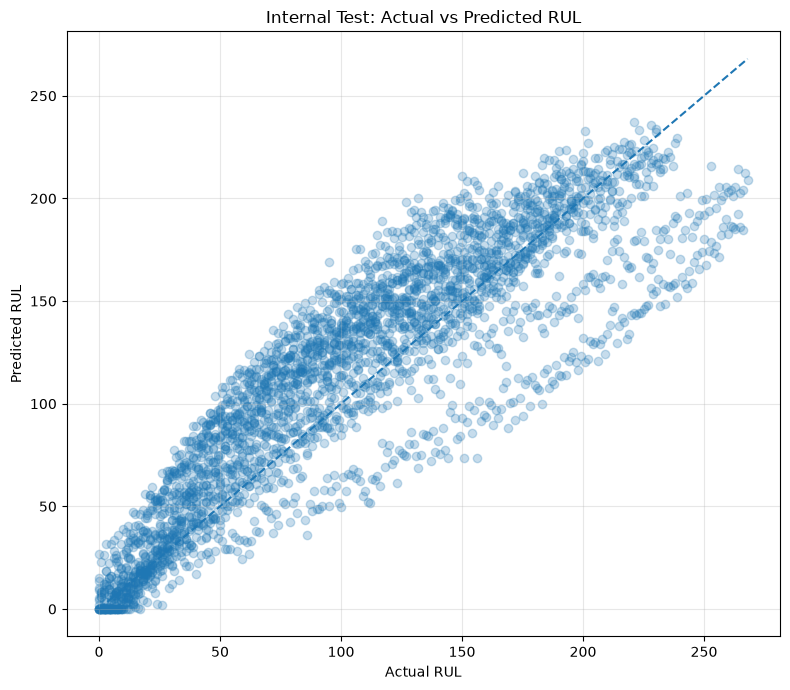

In [77]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_internal_test,
    internal_test_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_internal_test.min(),
    internal_test_predictions.min(),
)

maximum_value = max(
    y_internal_test.max(),
    internal_test_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title(
    "Internal Test: Actual vs Predicted RUL"
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "fd001_internal_test_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [78]:
internal_test_results_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "fd001_internal_test_regression_results.csv",
    index=False,
)

internal_test_regional_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "fd001_internal_test_regional_results.csv",
    index=False,
)

validation_vs_test_df.to_csv(
    PROJECT_ROOT
    / "reports"
    / "tables"
    / "fd001_validation_vs_internal_test.csv",
    index=False,
)

print(
    "Internal-test regression results saved."
)

Internal-test regression results saved.


In [79]:
import joblib

model_directory = (
    PROJECT_ROOT
    / "artifacts"
    / "models"
)

model_directory.mkdir(
    parents=True,
    exist_ok=True,
)

model_artifact = {
    "model": final_candidate_model,
    "feature_columns": final_feature_columns,
    "subset": "FD001",
    "model_type": "Polynomial Ridge",
    "polynomial_degree": 2,
    "ridge_alpha": 0.01,
    "selection_metric": "Validation NASA Score",
    "training_engine_count": 85,
}

model_path = (
    model_directory
    / "fd001_polynomial_ridge_candidate.joblib"
)

joblib.dump(
    model_artifact,
    model_path,
)

print(f"Model saved to: {model_path}")

Model saved to: c:\Users\User\Desktop\ML\FinalProject\artifacts\models\fd001_polynomial_ridge_candidate.joblib
